# packs

In [ ]:
from transformers import AutoModel
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
import numpy as np

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# !pip install datasets
!pip install datasets==1.18.3

In [ ]:
from datasets import Dataset

# functions

## read data functions

In [ ]:
def read_json(json_path):
  with open(json_path, 'r') as f:
    data = json.load(f)
    return data

In [ ]:
def read_jsonl_file(nl_file_path, return_df=True):
    """
    :param return_df: return df with 'text', 'key', 'text_translated' columns
    :param nl_file_path:
    :return: list of dicts(keys: 'text', 'key', 'text_translated') per translation
    """
    with open(nl_file_path, 'r') as f:
        jsonl_content = f.read()
        result = [json.loads(jline) for jline in jsonl_content.splitlines()]
    if return_df:
        return pd.DataFrame(result)
    return result

In [ ]:
def get_labels_tensor_from_data(data, label_key_name='label', labels_mapping = {'c': 0, 'e': 1, 'n': 2}, data_is_df=False):
  if data_is_df:
    str_labels = data[label_key_name].tolist()
  else:
    str_labels = [sample_[label_key_name] for sample_ in data]
  y = torch.tensor([labels_mapping[str_label.lower()] for str_label in str_labels], dtype=torch.int64)
  return y

In [ ]:
def set_seed(seed):
    """
    Set the seed for reproducibility.

    Args:
        seed (int): The seed value to set.
    """
    # Set seed for Python's random module
    random.seed(seed)

    # Set seed for NumPy
    np.random.seed(seed)

    # Set seed for PyTorch CPU
    torch.manual_seed(seed)

    # Set seed for PyTorch CUDA
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # If you are using multiple GPUs

    # Ensure that CUDA operations are deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## eval model

In [ ]:
def evaluate_model(model, test_x, y_test, labels_mapping, batch_size=32, device='cuda'):
    """
    Evaluates the given model on the test data and visualizes the results.

    Args:
        model (torch.nn.Module): The PyTorch model to evaluate.
        test_x (torch.Tensor): The input features for testing.
        y_test (torch.Tensor): The ground truth labels for testing.
        labels_mapping (dict): Dictionary mapping labels to indices.
        batch_size (int): The batch size for evaluation. Default is 32.
        device (str): The device to run the model on ('cuda' or 'cpu'). Default is 'cuda'.

    Returns:
        tuple: (predictions, accuracy, report) where:
            - predictions (torch.Tensor): The model's predictions on the test data.
            - accuracy (float): The accuracy of the model on the test data.
            - report (str): The classification report as a string.
    """
    model.eval()  # Set the model to evaluation mode

    # Move model and data to the specified device
    model.to(device)
    test_x = test_x.to(device)
    y_test = y_test.to(device)

    # Create a DataLoader for test data
    test_dataset = TensorDataset(test_x, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():  # No need to track gradients during evaluation
        for inputs, labels in test_loader:
            outputs = model(inputs)  # Forward pass
            _, preds = torch.max(outputs, 1)  # Get predictions
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    # Concatenate all predictions and labels
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Calculate accuracy
    correct = (all_preds == all_labels).sum().item()
    accuracy = correct / len(all_labels)

    # Mapping labels
    labels = [label for label, _ in sorted(labels_mapping.items(), key=lambda item: item[1])]

    # Compute and display confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=list(labels_mapping.values()))
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # Compute and display classification report
    report = classification_report(all_labels, all_preds, target_names=labels, digits=5)
    print("Classification Report:")
    print(report)

    return all_preds, accuracy, report

In [ ]:
def evaluate_model_base_on_preds_and_res(y_preds, y_test, labels_mapping):
    # Calculate accuracy
    correct = (y_preds == y_test).sum().item()
    accuracy = correct / len(y_test)

    # Mapping labels
    labels = [label for label, _ in sorted(labels_mapping.items(), key=lambda item: item[1])]

    # Compute and display confusion matrix
    cm = confusion_matrix(y_test, y_preds, labels=list(labels_mapping.values()))
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # Compute and display classification report
    report = classification_report(y_test, y_preds, target_names=labels, digits=5)
    print("Classification Report:")
    print(report)

    return y_preds, accuracy, report

## inference functions

In [ ]:
def extract_classifications_from_sample(model, tokenizer, sample, device, max_length=4096):

  inputs = tokenizer(sample, return_tensors="pt", truncation=True, padding="max_length", max_length=max_length).to(device)

  with torch.no_grad():
    outputs = model(**inputs)

  model_calssifications = outputs.logits.argmax(axis=1).cpu()
  return model_calssifications


def extract_embeddings_from_sample(model, tokenizer, sample, device, max_length=4096):

  inputs = tokenizer(sample, return_tensors="pt", truncation=True, padding="max_length", max_length=max_length).to(device)

  with torch.no_grad():
    outputs = model(**inputs)

  cls_embedding = outputs.last_hidden_state[:, 0, :].cpu()
  return cls_embedding


def extract_classifications_per_premise_hypothesis(model, tokenizer, device, data,
                                                   data_is_df=False,
                                                   premise_col_name='premise',
                                                   hypothesis_col_name='hypothesis',
                                                   inference_batch_size=10, max_length=4096,
                                                   ):
  model.to(device)

  model_classifications = []

  for i in tqdm(range(0, len(data), inference_batch_size)):
    if not data_is_df:
      batched_data = data[i:i+inference_batch_size]
      batch_df = pd.DataFrame(batched_data)
    else:
      batch_df = data.iloc[i:i+inference_batch_size]


    batch_cat_x = batch_df[premise_col_name] + ' [SEP] ' + batch_df[hypothesis_col_name] + ' [SEP] '
    cls_classi = extract_classifications_from_sample(model=model, tokenizer=tokenizer,
                                             device=device, sample=batch_cat_x.tolist(),
                                             max_length=max_length)

    model_classifications.append(cls_classi)

    # clean cuda mem
    del batched_data, batch_df, batch_cat_x, cls_classi
    torch.cuda.empty_cache()

  return torch.cat(model_classifications, dim=0)



def extract_embeddings_per_premise_hypothesis(model, tokenizer, device, data,
                                              data_is_df=False,
                                              premise_col_name='premise',
                                              hypothesis_col_name='hypothesis',
                                              inference_batch_size=10, max_length=4096,
                                              ):
  model.to(device)

  embeddings_ = []

  for i in tqdm(range(0, len(data), inference_batch_size)):
    if not data_is_df:
      batched_data = data[i:i+inference_batch_size]
      batch_df = pd.DataFrame(batched_data)
    else:
      batch_df = data.iloc[i:i+inference_batch_size]


    batch_cat_x = batch_df[premise_col_name] + ' [SEP] ' + batch_df[hypothesis_col_name] + ' [SEP] '
    cls_emb = extract_embeddings_from_sample(model=model, tokenizer=tokenizer,
                                             device=device, sample=batch_cat_x.tolist(),
                                             max_length=max_length)

    embeddings_.append(cls_emb)

    # clean cuda mem
    del batched_data, batch_df, batch_cat_x, cls_emb
    torch.cuda.empty_cache()

  return torch.cat(embeddings_, dim=0)

def run_and_save_embeddings_per_data_type(train_data, dev_data, test_data,
                                          model_name, model, tokenizer, device, destination_folder_path,
                                          max_length=4096, inference_batch_size=10, data_is_df=False,
                                          premise_col_name='premise', hypothesis_col_name='hypothesis',
                                          datasets_to_embbed=[1,1,1]):

  print(f'Extracting dataset embeddings by {model_name} model')

  if datasets_to_embbed[0] == 1:
    print(f'Extracting train...')
    train_embeddings = extract_embeddings_per_premise_hypothesis(model=model, tokenizer=tokenizer, device=device, data=train_data, max_length=max_length,
                                                                inference_batch_size=inference_batch_size, data_is_df=data_is_df,
                                                                premise_col_name=premise_col_name, hypothesis_col_name=hypothesis_col_name)
    path_train = f'{destination_folder_path}/{model_name}_x_train.pt'
    torch.save(train_embeddings, path_train)
    print(f'Saved train x ({path_train})')

  if datasets_to_embbed[1] == 1:
    print(f'Extracting dev...')
    dev_embeddings = extract_embeddings_per_premise_hypothesis(model=model, tokenizer=tokenizer, device=device, data=dev_data, max_length=max_length,
                                                              inference_batch_size=inference_batch_size, data_is_df=data_is_df,
                                                              premise_col_name=premise_col_name, hypothesis_col_name=hypothesis_col_name)
    path_dev = f'{destination_folder_path}/{model_name}_x_dev.pt'
    torch.save(dev_embeddings, path_dev)
    print(f'Saved dev x ({path_dev})')

  if datasets_to_embbed[2] == 1:
    print(f'Extracting test...')
    test_embeddings = extract_embeddings_per_premise_hypothesis(model=model, tokenizer=tokenizer, device=device, data=test_data, max_length=max_length,
                                                                inference_batch_size=inference_batch_size, data_is_df=data_is_df,
                                                                premise_col_name=premise_col_name, hypothesis_col_name=hypothesis_col_name)
    path_test = f'{destination_folder_path}/{model_name}_x_test.pt'
    torch.save(test_embeddings, path_test)
    print(f'Saved test x ({path_test})')

def tokenize_one_sample(tokenizer, sample, max_length):
  return tokenizer(sample, return_tensors="pt", truncation=True, padding="max_length", max_length=max_length)

def tokenize_in_batches(tokenizer, data_pairs, max_length=512, tokenizer_batch_size=128):
  n_samples = len(data_pairs)
  tokenized_data = []
  for i in tqdm(range(0, n_samples, tokenizer_batch_size)):
    sample = data_pairs[i:i+tokenizer_batch_size]
    tokenized_batch = tokenize_one_sample(tokenizer=tokenizer, sample=sample,
                                          max_length=max_length)
    tokenized_data.append(tokenized_batch)
  return tokenized_data

## train functions

In [ ]:
def create_dataloader(x, y, batch_size=32, shuffle=True):
  dataset = TensorDataset(x, y)
  loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
  return loader

def train_step(model, data_loader, loss_fn, optimizer, device):
  model.train()  # Set the model to training mode
  for inputs, targets in tqdm(data_loader):
    inputs, targets = inputs.to(device), targets.to(device)

    # Zero the gradients
    optimizer.zero_grad()
    # Forward pass
    outputs = model(inputs)
    loss = loss_fn(outputs, targets)

    # Backward pass and optimize
    loss.backward()
    optimizer.step()

def validate_model(model, data_loader, loss_fn, device):
  model.eval()  # Set the model to evaluation mode
  total_loss = 0
  correct_predictions = 0

  with torch.no_grad():
      for inputs, targets in tqdm(data_loader):
          inputs, targets = inputs.to(device), targets.to(device)
          outputs = model(inputs)
          loss = loss_fn(outputs, targets)
          total_loss += loss.item()

          # For multi-class classification, use argmax to get the predicted class
          predicted_classes = outputs.argmax(dim=1)
          correct_predictions += (predicted_classes == targets).sum().item()

  average_loss = total_loss / len(data_loader)
  accuracy = correct_predictions / len(data_loader.dataset)
  return average_loss, accuracy


def train_model(x_train, y_train, x_val, y_val, model, epochs, checkpoints_dir_path, batch_size=32, learning_rate=1e-4, weight_decay=1e-2, save_checkpoints=True):
  # Move model to the appropriate compute device
  device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
  model.to(device)

  # Create training and validation data loaders
  train_loader = create_dataloader(x_train, y_train, batch_size, shuffle=True)
  val_loader = create_dataloader(x_val, y_val, batch_size, shuffle=False)

  # Define loss function and optimizer
  loss_fn = nn.CrossEntropyLoss()
  # optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

  train_losses, val_losses = [],[]

  # Training loop
  for epoch in range(epochs):
    print(f'\n\n**Epoch #{epoch+1}')
    train_step(model, train_loader, loss_fn, optimizer, device)

    print('Finished training step, checking loss on train')
    train_loss, train_accuracy = validate_model(model, train_loader, loss_fn, device)
    train_losses.append(train_loss)

    print('Checking loss on validation')
    val_loss, val_accuracy = validate_model(model, val_loader, loss_fn, device)
    val_losses.append(val_loss)

    print(f'Train Epoch {epoch+1}/{epochs} Stats- Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}; Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

    # Save checkpoints
    if save_checkpoints:
      torch.save(model.state_dict(), f'{checkpoints_dir_path}/epoch_{epoch+1}_{round(val_loss,2)}_val_loss.pth')
      np.save(f'{checkpoints_dir_path}/train_losses.npy', np.array(train_losses))
      np.save(f'{checkpoints_dir_path}/val_losses.npy', np.array(val_losses))

  print("Training complete!")


In [ ]:
def compute_accuracy(labels, preds):
    # Convert logits to predicted class (0 or 1)
    pred_labels = np.argmax(preds, axis=1)
    # Calculate accuracy
    accuracy = (labels == pred_labels).mean()
    return {"accuracy": accuracy}

# Function to compute metrics for Hugging Face Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    return compute_accuracy(labels, logits)

# read data

## HEB SNLI

In [ ]:
snli_train_path_file = '____path____data/SNLI/HebNLI_train.jsonl'
snli_dev_path_file = '____path____data/SNLI/HebNLI_val.jsonl'
snli_test_path_file = '____path____data/SNLI/HebNLI_test.jsonl'

In [ ]:
snli_train_data = read_jsonl_file(snli_train_path_file)
snli_dev_data = read_jsonl_file(snli_dev_path_file)
snli_test_data = read_jsonl_file(snli_test_path_file)

In [ ]:
snli_labels_mapping = {'contradiction': 0, 'entailment': 1, 'neutral': 2, '-':3}
snli_y_train = get_labels_tensor_from_data(snli_train_data, labels_mapping=snli_labels_mapping, label_key_name='original_label', data_is_df=True)
snli_y_dev = get_labels_tensor_from_data(snli_dev_data, labels_mapping=snli_labels_mapping, label_key_name='original_label', data_is_df=True)
snli_y_test = get_labels_tensor_from_data(snli_test_data, labels_mapping=snli_labels_mapping, label_key_name='original_label', data_is_df=True)

In [ ]:
snli_y_train.shape, snli_y_dev.shape, snli_y_test.shape

(torch.Size([300150]), torch.Size([2000]), torch.Size([884]))

In [ ]:
map_cleaned_train_samples = (snli_y_train != 3).numpy()
map_cleaned_dev_samples = (snli_y_dev != 3).numpy()
map_cleaned_test_samples = (snli_y_test != 3).numpy()

In [ ]:
snli_train_data = snli_train_data[map_cleaned_train_samples].reset_index(drop=True)
snli_dev_data = snli_dev_data[map_cleaned_dev_samples].reset_index(drop=True)
snli_test_data = snli_test_data[map_cleaned_test_samples].reset_index(drop=True)

In [ ]:
snli_y_train = snli_y_train[map_cleaned_train_samples]
snli_y_dev = snli_y_dev[map_cleaned_dev_samples]
snli_y_test = snli_y_test[map_cleaned_test_samples]

## HEB Control (LCHAIM)

### DIKTA

In [ ]:
train_path_file = '____path____data/translations/dikta_train_data.parquet'
dev_path_file = '____path____data/translations/dikta_heb_dev.json'
test_path_file = '____path____data/translations/dikta_heb_test.json'

In [ ]:
train_data_parquet = pd.read_parquet(train_path_file)
train_data = train_data_parquet.to_dict(orient='records')
dev_data = read_json(dev_path_file)
test_data = read_json(test_path_file)

In [ ]:
y_train = get_labels_tensor_from_data(train_data)
y_dev = get_labels_tensor_from_data(dev_data)
y_test = get_labels_tensor_from_data(test_data)

In [ ]:
y_train.shape, y_dev.shape, y_test.shape

(torch.Size([6719]), torch.Size([799]), torch.Size([805]))

### AWS

In [ ]:
train_path_file = '____path____data/translations/aws_heb_train.json'
dev_path_file = '____path____data/translations/aws_heb_dev.json'
test_path_file = '____path____data/translations/aws_heb_test.json'

In [ ]:
train_data = read_json(train_path_file)
dev_data = read_json(dev_path_file)
test_data = read_json(test_path_file)

In [ ]:
uids_to_remove_from_aws_data = ['id_2456','id_2457','id_2458','id_2459'] #text_2851 wasn't translated
def filter_dicts(list_of_dicts, values_to_exclude, key_name):
    return [d for d in list_of_dicts if d.get(key_name) not in values_to_exclude]

train_data = filter_dicts(list_of_dicts=train_data, values_to_exclude=uids_to_remove_from_aws_data, key_name='uid')

In [ ]:
y_train = get_labels_tensor_from_data(train_data)
y_dev = get_labels_tensor_from_data(dev_data)
y_test = get_labels_tensor_from_data(test_data)

In [ ]:
y_train.shape, y_dev.shape, y_test.shape

(torch.Size([6715]), torch.Size([799]), torch.Size([805]))

## Control origin CONTROL

In [ ]:
train_path_file = '____path____data/control_eng/train.jsonl'
dev_path_file = '____path____data/control_eng/dev.jsonl'
test_path_file = '____path____data/control_eng/test.jsonl'

In [ ]:
train_data = read_jsonl_file(train_path_file, return_df=False)
dev_data = read_jsonl_file(dev_path_file, return_df=False)
test_data = read_jsonl_file(test_path_file, return_df=False)

In [ ]:
y_train = get_labels_tensor_from_data(train_data)
y_dev = get_labels_tensor_from_data(dev_data)
y_test = get_labels_tensor_from_data(test_data)

In [ ]:
y_train.shape, y_dev.shape, y_test.shape

## ENG LCHAIM

In [ ]:
train_path_file = '____path____data/eng_lchaim/eng_lchaim_train.json'
dev_path_file = '____path____data/eng_lchaim/eng_lchaim_dev.json'
test_path_file = '____path____data/eng_lchaim/eng_lchaim_test.json'

In [ ]:
train_data = read_json(train_path_file)
dev_data = read_json(dev_path_file)
test_data = read_json(test_path_file)

In [ ]:
uids_to_remove_from_train_eng_lchaim_train_data = ['id_966', 'id_967', 'id_968', 'id_969', 'id_970', 'id_1231',
                                             'id_1232', 'id_1233', 'id_1234', 'id_1235', 'id_1592', 'id_1593',
                                             'id_1594', 'id_1595', 'id_1596', 'id_1597', 'id_1598', 'id_1599',
                                             'id_1655', 'id_1656', 'id_1657', 'id_1658', 'id_1659', 'id_1660',
                                             'id_1661', 'id_1952', 'id_1953', 'id_1954', 'id_1955', 'id_1956',
                                             'id_1957', 'id_2451', 'id_2452', 'id_2453', 'id_2454', 'id_2455',
                                             'id_2456', 'id_2457', 'id_2458', 'id_2459', 'id_2468', 'id_2469',
                                             'id_2470', 'id_2471', 'id_2728', 'id_2729', 'id_2730', 'id_3458',
                                             'id_3459', 'id_3460', 'id_3461', 'id_3462', 'id_3463', 'id_3464',
                                             'id_3465', 'id_3857', 'id_3858', 'id_3859', 'id_3860', 'id_3861',
                                             'id_3862', 'id_3863', 'id_3864', 'id_3865', 'id_3866', 'id_3867',
                                             'id_3868', 'id_4128', 'id_4129', 'id_4130', 'id_4131', 'id_4454',
                                             'id_4455', 'id_4456', 'id_4457', 'id_4458', 'id_4459', 'id_4460',
                                             'id_4461', 'id_4462', 'id_4463', 'id_5027', 'id_5028', 'id_5029',
                                             'id_5030', 'id_5816', 'id_5817', 'id_5818', 'id_5819', 'id_5820',
                                             'id_5907', 'id_5908', 'id_5909', 'id_5910', 'id_5911', 'id_5912',
                                             'id_5913', 'id_5914', 'id_6002', 'id_6003', 'id_6004', 'id_6005',
                                             'id_6006', 'id_6007', 'id_6008', 'id_6411', 'id_6412', 'id_6413',
                                             'id_6414'] #many texts werent translated and they got None
uids_to_remove_from_train_eng_lchaim_test_data = ['id_331', 'id_332', 'id_333', 'id_334', 'id_335', 'id_336', 'id_337'] # text text_9087 wasnt translated


def filter_dicts(list_of_dicts, values_to_exclude, key_name):
    return [d for d in list_of_dicts if d.get(key_name) not in values_to_exclude]

train_data = filter_dicts(list_of_dicts=train_data, values_to_exclude=uids_to_remove_from_train_eng_lchaim_train_data, key_name='uid')
test_data = filter_dicts(list_of_dicts=test_data, values_to_exclude=uids_to_remove_from_train_eng_lchaim_test_data, key_name='uid')

In [ ]:
y_train = get_labels_tensor_from_data(train_data)
y_dev = get_labels_tensor_from_data(dev_data)
y_test = get_labels_tensor_from_data(test_data)

In [ ]:
y_train.shape, y_dev.shape, y_test.shape

(torch.Size([6610]), torch.Size([799]), torch.Size([798]))

# FineTuning

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model_name = 'longhero'
# model_path = 'onlplab/alephbert-base'
model_path = 'HeNLP/LongHeRo'

In [ ]:
snli_context_window = 256
lchaim_context_window = 4096

## relvant model loading

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=3)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of LongformerForSequenceClassification were not initialized from the model che

## preprocess data

### HEB SNLI

In [ ]:
snli_train_df = pd.DataFrame(snli_train_data)
snli_dev_df = pd.DataFrame(snli_dev_data)
snli_test_df = pd.DataFrame(snli_test_data)

In [ ]:
snli_train_df['paires'] = snli_train_df['translation1'] + ' [SEP] ' + snli_train_df['translation2'] + ' [SEP] '
snli_dev_df['paires'] = snli_dev_df['translation1'] + ' [SEP] ' + snli_dev_df['translation2'] + ' [SEP] '
snli_test_df['paires'] = snli_test_df['translation1'] + ' [SEP] ' + snli_test_df['translation2'] + ' [SEP] '

In [ ]:
snli_train_pairs = snli_train_df['paires'].tolist()
snli_dev_pairs = snli_dev_df['paires'].tolist()
snli_test_pairs = snli_test_df['paires'].tolist()

In [ ]:
snli_tokenized_train = tokenize_one_sample(tokenizer=tokenizer, sample=snli_train_pairs, max_length=snli_context_window)
snli_tokenized_dev = tokenize_one_sample(tokenizer=tokenizer, sample=snli_dev_pairs, max_length=snli_context_window)
snli_tokenized_test = tokenize_one_sample(tokenizer=tokenizer, sample=snli_test_pairs, max_length=snli_context_window)

In [ ]:
snli_train_data = Dataset.from_dict({
    'input_ids': snli_tokenized_train['input_ids'],
    'attention_mask': snli_tokenized_train['attention_mask'],
    'labels': snli_y_train
})

snli_dev_data = Dataset.from_dict({
    'input_ids': snli_tokenized_dev['input_ids'],
    'attention_mask': snli_tokenized_dev['attention_mask'],
    'labels': snli_y_dev
})

snli_test_data = Dataset.from_dict({
    'input_ids': snli_tokenized_test['input_ids'],
    'attention_mask': snli_tokenized_test['attention_mask'],
    'labels': snli_y_test
})

### LCHAIM

In [ ]:
train_df = pd.DataFrame(train_data)
dev_df = pd.DataFrame(dev_data)
test_df = pd.DataFrame(test_data)

In [ ]:
train_df['paires'] = train_df['premise'] + ' [SEP] ' + train_df['hypothesis'] + ' [SEP] '
dev_df['paires'] = dev_df['premise'] + ' [SEP] ' + dev_df['hypothesis'] + ' [SEP] '
test_df['paires'] = test_df['premise'] + ' [SEP] ' + test_df['hypothesis'] + ' [SEP] '

In [ ]:
train_pairs = train_df['paires'].tolist()
dev_pairs = dev_df['paires'].tolist()
test_pairs = test_df['paires'].tolist()

In [ ]:
tokenized_train = tokenize_one_sample(tokenizer=tokenizer, sample=train_pairs, max_length=lchaim_context_window)
tokenized_dev = tokenize_one_sample(tokenizer=tokenizer, sample=dev_pairs, max_length=lchaim_context_window)
tokenized_test = tokenize_one_sample(tokenizer=tokenizer, sample=test_pairs, max_length=lchaim_context_window)

In [ ]:
lchaim_train_data = Dataset.from_dict({
    'input_ids': tokenized_train['input_ids'],
    'attention_mask': tokenized_train['attention_mask'],
    'labels': y_train
})

lchaim_dev_data = Dataset.from_dict({
    'input_ids': tokenized_dev['input_ids'],
    'attention_mask': tokenized_dev['attention_mask'],
    'labels': y_dev
})

lchaim_test_data = Dataset.from_dict({
    'input_ids': tokenized_test['input_ids'],
    'attention_mask': tokenized_test['attention_mask'],
    'labels': y_test
})


## Run training

### HEB-SNLI+LCHAIM

#### HEB SNLI

In [ ]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=1e-5,
    warmup_steps=500,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=10
)

In [ ]:
snli_trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=snli_train_data,
    eval_dataset=snli_dev_data,
    compute_metrics=compute_metrics,
)

In [ ]:
snli_trainer.train()

In [ ]:
model.save_pretrained('____path____finetuning/snli')
tokenizer.save_pretrained('____path____finetuning/snli')

('____path____finetuning/snli/tokenizer_config.json',
 '____path____finetuning/snli/special_tokens_map.json',
 '____path____finetuning/snli/vocab.txt',
 '____path____finetuning/snli/added_tokens.json',
 '____path____finetuning/snli/tokenizer.json')

In [ ]:
results = snli_trainer.predict(test_dataset=snli_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics

SNLI test set after FT on SNLI


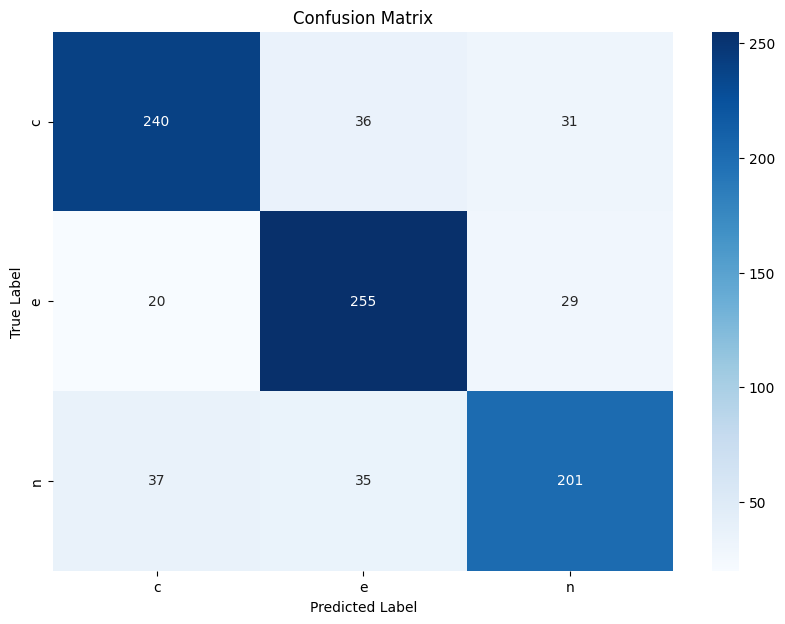

Classification Report:
              precision    recall  f1-score   support

           c    0.80808   0.78176   0.79470       307
           e    0.78221   0.83882   0.80952       304
           n    0.77011   0.73626   0.75281       273

    accuracy                        0.78733       884
   macro avg    0.78680   0.78561   0.78568       884
weighted avg    0.78746   0.78733   0.78686       884



In [ ]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print('SNLI test set after FT on SNLI')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=snli_y_test.numpy(), labels_mapping=labels_mapping)

In [ ]:
results = snli_trainer.predict(test_dataset=lchaim_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics

In [ ]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print('AWS LCHAIM test set after FT on SNLI')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=y_test.numpy(), labels_mapping=labels_mapping)

AWS LCHAIM test set after FT on SNLI


Classification Report:
              precision    recall  f1-score   support

           c    0.28926   0.14463   0.19284       242
           e    0.42431   0.56575   0.48493       327
           n    0.33065   0.34746   0.33884       236

    accuracy                        0.37516       805
   macro avg    0.34807   0.35261   0.33887       805
weighted avg    0.35625   0.37516   0.35429       805



####LCHAIM

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('____path____finetuning/snli')
model = AutoModelForSequenceClassification.from_pretrained('____path____finetuning/snli')

In [ ]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=1e-5,
    warmup_steps=500,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=10
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1494: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
lchaim_trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=lchaim_train_data,
    eval_dataset=lchaim_dev_data,
    compute_metrics=compute_metrics
)
lchaim_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.089800,1.091598,0.413016
2,1.037600,1.044225,0.463079


TrainOutput(global_step=420, training_loss=1.1099617186046782, metrics={'train_runtime': 552.2624, 'train_samples_per_second': 24.318, 'train_steps_per_second': 0.761, 'total_flos': 3533613200087040.0, 'train_loss': 1.1099617186046782, 'epoch': 2.0})

In [ ]:
model.save_pretrained('____path____finetuning/ft_aws_snli')
tokenizer.save_pretrained('____path____finetuning/ft_aws_snli')

('____path____finetuning/ft_aws_snli/tokenizer_config.json',
 '____path____finetuning/ft_aws_snli/special_tokens_map.json',
 '____path____finetuning/ft_aws_snli/vocab.txt',
 '____path____finetuning/ft_aws_snli/added_tokens.json',
 '____path____finetuning/ft_aws_snli/tokenizer.json')

In [ ]:
results = lchaim_trainer.predict(test_dataset=lchaim_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics

AWS LCHAIM test set after FT on SNLI+AWS-LCHAIM


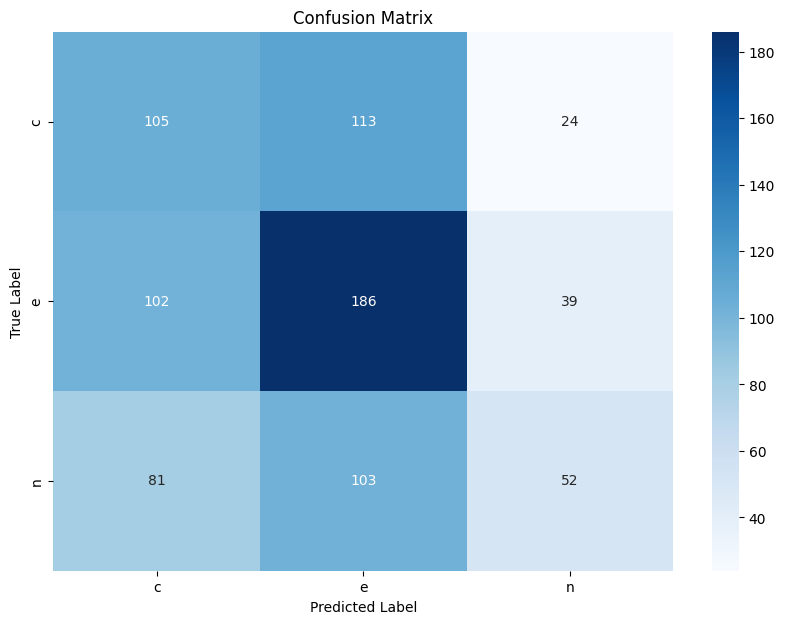

Classification Report:
              precision    recall  f1-score   support

           c    0.36458   0.43388   0.39623       242
           e    0.46269   0.56881   0.51029       327
           n    0.45217   0.22034   0.29630       236

    accuracy                        0.42609       805
   macro avg    0.42648   0.40768   0.40094       805
weighted avg    0.43011   0.42609   0.41326       805



In [ ]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print('AWS LCHAIM test set after FT on SNLI+AWS-LCHAIM')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=y_test.numpy(), labels_mapping=labels_mapping)

SNLI test set after FT on SNLI+AWS-LCHAIM


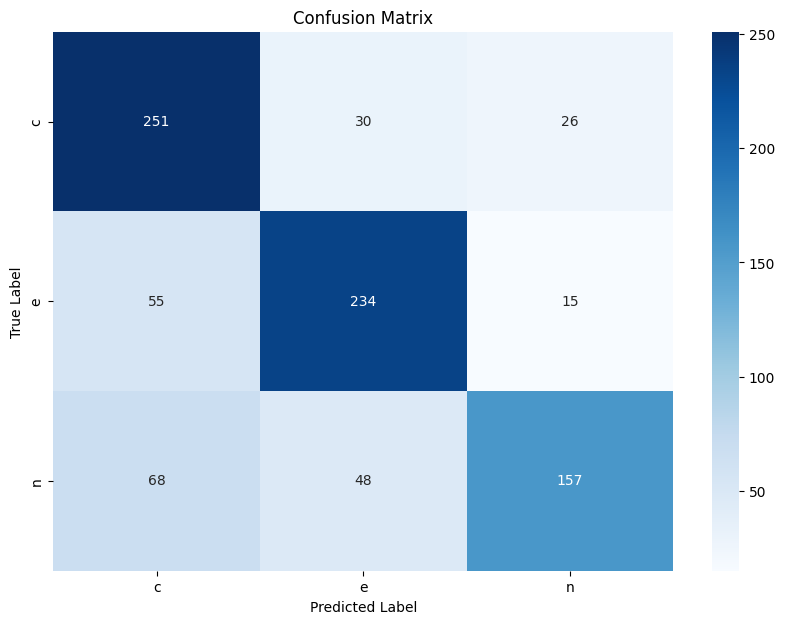

Classification Report:
              precision    recall  f1-score   support

           c    0.67112   0.81759   0.73715       307
           e    0.75000   0.76974   0.75974       304
           n    0.79293   0.57509   0.66667       273

    accuracy                        0.72624       884
   macro avg    0.73802   0.72081   0.72119       884
weighted avg    0.73586   0.72624   0.72315       884



In [ ]:
results = lchaim_trainer.predict(test_dataset=snli_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print('SNLI test set after FT on SNLI+AWS-LCHAIM')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=snli_y_test.numpy(), labels_mapping=labels_mapping)

### LCHAIM+HEB-SNLI

In [ ]:
method_of_ft = 'lchaim+heb_snli'

In [ ]:
lcahim_model_path = f'____path____finetuning {model_name}/{method_of_ft}/lchaim'
heb_snli_model_path = f'____path____finetuning {model_name}/{method_of_ft}/heb_snli'
lcahim_model_path,heb_snli_model_path

('____path____finetuning longhero/lchaim+heb_snli/lchaim',
 '____path____finetuning longhero/lchaim+heb_snli/heb_snli')

####FT LCHAIM

In [ ]:
b_size = 8

In [ ]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=b_size,
    per_device_eval_batch_size=b_size,
    learning_rate=1e-5,
    warmup_steps=1,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=10
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
lchaim_trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=lchaim_train_data,
    eval_dataset=lchaim_dev_data,
    compute_metrics=compute_metrics
)
lchaim_trainer.train()

Initializing global attention on CLS token...
Input ids are automatically padded to be a multiple of `config.attention_window`: 512


Epoch,Training Loss,Validation Loss,Accuracy
1,1.090900,1.108289,0.350438


In [ ]:
model.save_pretrained(lcahim_model_path)
tokenizer.save_pretrained(lcahim_model_path)

longhero: LCHAIM test set after FT on LCHAIM


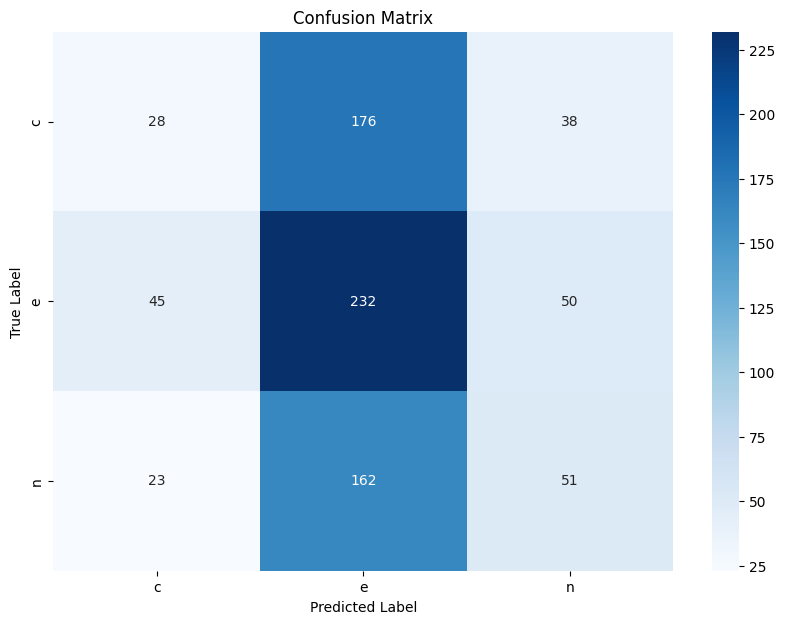

Classification Report:
              precision    recall  f1-score   support

           c    0.29167   0.11570   0.16568       242
           e    0.40702   0.70948   0.51728       327
           n    0.36691   0.21610   0.27200       236

    accuracy                        0.38634       805
   macro avg    0.35520   0.34709   0.31832       805
weighted avg    0.36058   0.38634   0.33967       805



In [ ]:
results = lchaim_trainer.predict(test_dataset=lchaim_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print(f'{model_name}: LCHAIM test set after FT on LCHAIM')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=y_test.numpy(), labels_mapping=labels_mapping)

longhero: SNLI test set after FT on LCHAIM


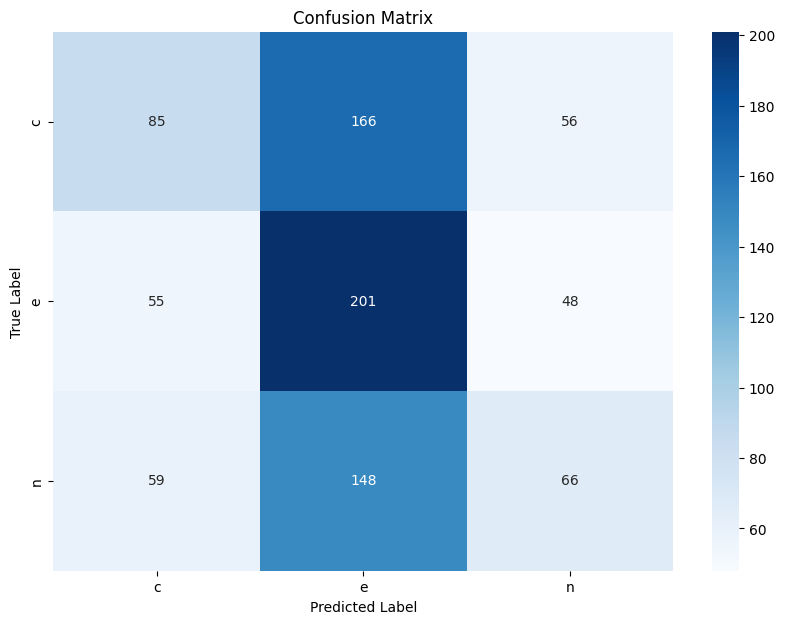

Classification Report:
              precision    recall  f1-score   support

           c    0.42714   0.27687   0.33597       307
           e    0.39029   0.66118   0.49084       304
           n    0.38824   0.24176   0.29797       273

    accuracy                        0.39819       884
   macro avg    0.40189   0.39327   0.37493       884
weighted avg    0.40245   0.39819   0.37749       884



In [ ]:
results = lchaim_trainer.predict(test_dataset=snli_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print(f'{model_name}: SNLI test set after FT on LCHAIM')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=snli_y_test.numpy(), labels_mapping=labels_mapping)

#### FT HEB SNLI (AFTER LCHAIM)

In [ ]:
snli_b_size = 8*4

In [ ]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=snli_b_size,
    per_device_eval_batch_size=snli_b_size,
    learning_rate=1e-5,
    warmup_steps=500,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=10
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
snli_trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=snli_train_data,
    eval_dataset=snli_dev_data,
    compute_metrics=compute_metrics,
)

In [ ]:
snli_trainer.train()

Initializing global attention on CLS token...
Input ids are automatically padded to be a multiple of `config.attention_window`: 512


Epoch,Training Loss,Validation Loss,Accuracy
1,0.556200,0.570369,0.777889


Epoch,Training Loss,Validation Loss,Accuracy
1,0.556200,0.570369,0.777889


In [ ]:
model.save_pretrained(heb_snli_model_path)
tokenizer.save_pretrained(heb_snli_model_path)

longhero: SNLI test set after FT on LCHAIM+HEB-SNLI


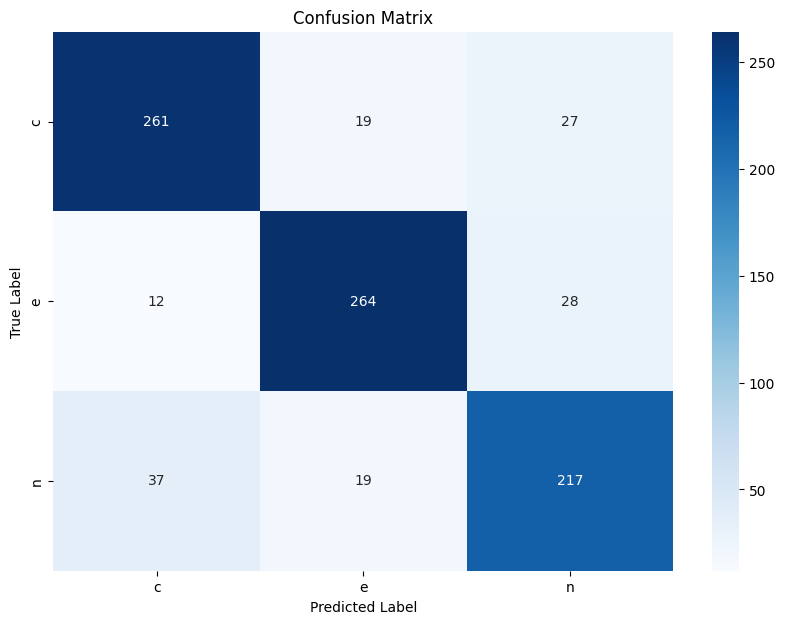

Classification Report:
              precision    recall  f1-score   support

           c    0.84194   0.85016   0.84603       307
           e    0.87417   0.86842   0.87129       304
           n    0.79779   0.79487   0.79633       273

    accuracy                        0.83937       884
   macro avg    0.83797   0.83782   0.83788       884
weighted avg    0.83939   0.83937   0.83937       884



In [ ]:
results = snli_trainer.predict(test_dataset=snli_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print(f'{model_name}: SNLI test set after FT on LCHAIM+HEB-SNLI')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=snli_y_test.numpy(), labels_mapping=labels_mapping)

longhero: LCHAIM test set after FT on LCHAIM+HEB-SNLI


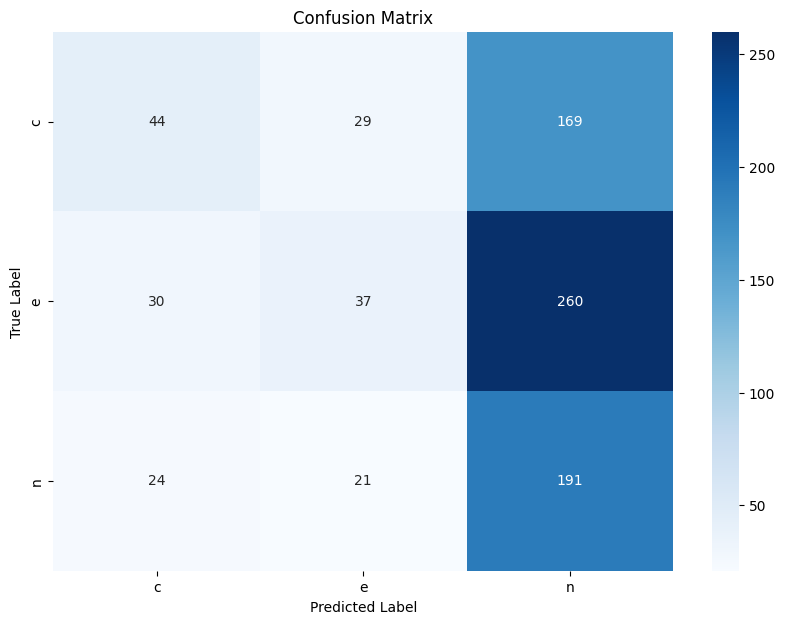

Classification Report:
              precision    recall  f1-score   support

           c    0.44898   0.18182   0.25882       242
           e    0.42529   0.11315   0.17874       327
           n    0.30806   0.80932   0.44626       236

    accuracy                        0.33789       805
   macro avg    0.39411   0.36810   0.29461       805
weighted avg    0.39804   0.33789   0.28125       805



In [ ]:
results = snli_trainer.predict(test_dataset=lchaim_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print(f'{model_name}: LCHAIM test set after FT on LCHAIM+HEB-SNLI')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=y_test.numpy(), labels_mapping=labels_mapping)

# Output hidden states per sample

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

## Origin Control (ENG)

### Bert-Base

In [ ]:
model_name = 'bert_base'
folder_to_save_data = f'____path____embeddings/control_eng/{model_name}'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModel.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
run_and_save_embeddings_per_data_type(train_data=train_data, dev_data=dev_data, test_data=test_data,
                                      model_name=model_name, model=model, tokenizer=tokenizer, device=device,
                                      max_length=512, inference_batch_size=512,
                                      destination_folder_path=folder_to_save_data,
                                      datasets_to_embbed=[1,0,0])

Extracting dataset embeddings by bert_base model
Extracting train...


100%|██████████| 14/14 [03:10<00:00, 13.61s/it]

Saved train x (____path____embeddings/control_eng/bert_base/bert_base_x_train.pt)


### LongFormer

In [ ]:
model_name = 'longformer'
folder_to_save_data = f'____path____embeddings/control_eng/{model_name}'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('allenai/longformer-base-4096')
model = AutoModel.from_pretrained('allenai/longformer-base-4096')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

In [ ]:
run_and_save_embeddings_per_data_type(train_data=train_data, dev_data=dev_data, test_data=test_data,
                                      model_name=model_name, model=model, tokenizer=tokenizer, device=device,
                                      max_length=4096, inference_batch_size=30,
                                      destination_folder_path=folder_to_save_data,
                                      datasets_to_embbed=[1,1,0])

Extracting dataset embeddings by longformer model
Extracting train...


100%|██████████| 224/224 [30:03<00:00,  8.05s/it]


Saved train x (____path____embeddings/control_eng/longformer/longformer_x_train.pt)
Extracting dev...


100%|██████████| 27/27 [03:35<00:00,  7.96s/it]

Saved dev x (____path____embeddings/control_eng/longformer/longformer_x_dev.pt)


## LCHAIM (HEB Control)

In [ ]:
translation_type = 'aws_translation'
dataset = 'lchaim'

In [ ]:
folder_to_save_data = f'____path____embeddings/{dataset}/{translation_type}'
folder_to_save_data

'____path____embeddings/lchaim/aws_translation'

### LongHero

In [ ]:
model_name = 'longhero'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('HeNLP/LongHeRo')
model = AutoModel.from_pretrained('HeNLP/LongHeRo')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.46M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.11M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.43M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Some weights of LongformerModel were not initialized from the model checkpoint at HeNLP/LongHeRo and are newly initialized: ['longformer.pooler.dense.bias', 'longformer.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
run_and_save_embeddings_per_data_type(train_data, dev_data, test_data,
                                      model_name, model, tokenizer, device,
                                      max_length=3000, inference_batch_size=25,
                                      destination_folder_path=folder_to_save_data,
                                      datasets_to_embbed=[1,0,0])

Extracting dataset embeddings by longhero model
Extracting train...


100%|██████████| 269/269 [32:25<00:00,  7.23s/it]

Saved train x (____path____embeddings/control/aws_translation/longhero_x_train.pt)


### AlephBert

In [ ]:
model_name = 'alephbert'

In [ ]:
folder_to_save_data = f'____path____embeddings/{dataset}/{translation_type}/{model_name}'
folder_to_save_data

'____path____embeddings/lchaim/aws_translation/alephbert'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('onlplab/alephbert-base')
model = AutoModel.from_pretrained('onlplab/alephbert-base')

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/545k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at onlplab/alephbert-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
run_and_save_embeddings_per_data_type(train_data=train_data,
                                      dev_data=dev_data,
                                      test_data=test_data,
                                      model_name=model_name,
                                      model=model, tokenizer=tokenizer,
                                      device=device, max_length=512, inference_batch_size=512,
                                      destination_folder_path=folder_to_save_data)

Extracting dataset embeddings by alephbert model
Extracting train...


100%|██████████| 14/14 [01:37<00:00,  6.96s/it]


Saved train x (____path____embeddings/lchaim/aws_translation/longhero/alephbert_x_train.pt)
Extracting dev...


100%|██████████| 2/2 [00:11<00:00,  5.79s/it]


Saved dev x (____path____embeddings/lchaim/aws_translation/longhero/alephbert_x_dev.pt)
Extracting test...


100%|██████████| 2/2 [00:11<00:00,  5.91s/it]

Saved test x (____path____embeddings/lchaim/aws_translation/longhero/alephbert_x_test.pt)


## SNLI

### AlephBert

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('onlplab/alephbert-base')
model = AutoModel.from_pretrained('onlplab/alephbert-base')
run_and_save_embeddings_per_data_type(snli_train_data, snli_dev_data, snli_test_data,
                                      model_name, model, tokenizer, device,
                                      max_length=512, inference_batch_size=512,
                                      destination_folder_path=f'{folder_to_save_data}/snli',
                                      premise_col_name='translation1', hypothesis_col_name='translation2'
                                      )

Extracting dataset embeddings by alephbert model
Extracting train...


100%|██████████| 587/587 [1:11:06<00:00,  7.27s/it]


Saved train x (____path____embeddings/alephbert_x_train.pt)
Extracting dev...


100%|██████████| 4/4 [00:28<00:00,  7.11s/it]


Saved dev x (____path____embeddings/alephbert_x_dev.pt)
Extracting test...


100%|██████████| 2/2 [00:12<00:00,  6.27s/it]

Saved test x (____path____embeddings/alephbert_x_test.pt)


### longhero

In [ ]:
model_name = 'longhero'
dataset='snli'

In [ ]:
folder_to_save_data = f'____path____embeddings/{dataset}/{model_name}'
folder_to_save_data

'____path____embeddings/snli/longhero'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('HeNLP/LongHeRo')
model = AutoModel.from_pretrained('HeNLP/LongHeRo')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of LongformerModel were not initialized from the model checkpoint at HeNLP/LongHeRo and are newly initialized: ['longformer.pooler.dense.bias', 'longformer.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
run_and_save_embeddings_per_data_type(snli_train_data, snli_dev_data, snli_test_data,
                                      model_name, model, tokenizer, device,
                                      max_length=512, inference_batch_size=256,
                                      destination_folder_path=folder_to_save_data,
                                      premise_col_name='translation1', hypothesis_col_name='translation2'
                                      )

Extracting dataset embeddings by longhero model
Extracting train...


 96%|█████████▌| 1127/1173 [2:36:58<06:24,  8.36s/it]

## ENG LCHAIM

### longformer

In [ ]:
model_name = 'longformer'
dataset='eng_lchaim'

In [ ]:
folder_to_save_data = f'____path____embeddings/{dataset}/{model_name}'
folder_to_save_data

'____path____embeddings/eng_lchaim/longformer'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('allenai/longformer-base-4096')
model = AutoModel.from_pretrained('allenai/longformer-base-4096')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

In [ ]:
run_and_save_embeddings_per_data_type(train_data, dev_data, test_data,
                                      model_name, model, tokenizer, device,
                                      max_length=4096, inference_batch_size=25,
                                      destination_folder_path=folder_to_save_data,
                                      datasets_to_embbed=[1,1,1])

Extracting dataset embeddings by longformer model
Extracting train...


100%|██████████| 265/265 [29:26<00:00,  6.66s/it]


Saved train x (____path____embeddings/eng_lchaim/longformer/longformer_x_train.pt)
Extracting dev...


100%|██████████| 32/32 [03:33<00:00,  6.67s/it]


Saved dev x (____path____embeddings/eng_lchaim/longformer/longformer_x_dev.pt)
Extracting test...


100%|██████████| 32/32 [03:32<00:00,  6.65s/it]

Saved test x (____path____embeddings/eng_lchaim/longformer/longformer_x_test.pt)


# Train MLP

In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, classifier_input_size=768):
        super(MLPClassifier, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Linear(classifier_input_size, 300), # l1
            nn.ReLU(),
            nn.LayerNorm(300),
            nn.Dropout(0.3),
            nn.Linear(300, 100), # l2
            nn.ReLU(),
            nn.LayerNorm(100),
            nn.Dropout(0.3),
            nn.Linear(100, 50), # l3
            nn.ReLU(),
            nn.LayerNorm(50),
        )
        self.output_layer = nn.Linear(50, 3)  # 3 classes

    def forward(self, x):
        x = self.hidden_layers(x)
        x = self.output_layer(x)
        return x


class MLPClassifier(nn.Module):
    def __init__(self, classifier_input_size=768):
        super(MLPClassifier, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(classifier_input_size, 3), # l1
        )

    def forward(self, x):
        x = self.hidden_layers(x)
        return x

## MLP LCHAIM

## MLP ENG LCHAIM

In [ ]:
model_name = 'longformer'
dataset_name = 'eng_lchaim'
folder_to_save_data = f'____path____embeddings/{dataset_name}/{model_name}'
folder_to_save_data

'____path____embeddings/eng_lchaim/longformer'

In [ ]:
train_embeddings = torch.load(f'{folder_to_save_data}/{model_name}_x_train.pt')
dev_embeddings = torch.load(f'{folder_to_save_data}/{model_name}_x_dev.pt')
test_embeddings = torch.load(f'{folder_to_save_data}/{model_name}_x_test.pt')

<ipython-input-30-111b369e26d1>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_embeddings = torch.load(f'{folder_to_save_data}/{model_name}_x_train.pt')
<ipython-inp

In [ ]:
set_seed(42)
classifier_model = MLPClassifier()
train_model(x_train=train_embeddings, y_train=y_train.long(), x_val=dev_embeddings, y_val=y_dev,
            model=classifier_model, learning_rate=1e-4, batch_size=32,
            epochs=10, checkpoints_dir_path='/content')



**Epoch #1


100%|██████████| 207/207 [00:00<00:00, 708.03it/s]


Finished training step, checking loss on train


100%|██████████| 207/207 [00:00<00:00, 1385.29it/s]


Checking loss on validation


100%|██████████| 25/25 [00:00<00:00, 1302.00it/s]


Train Epoch 1/10 Stats- Train Loss: 1.0932, Train Accuracy: 0.3667; Val Loss: 1.0966, Val Accuracy: 0.3592


**Epoch #2


100%|██████████| 207/207 [00:00<00:00, 699.51it/s]


Finished training step, checking loss on train


100%|██████████| 207/207 [00:00<00:00, 1377.49it/s]


Checking loss on validation


100%|██████████| 25/25 [00:00<00:00, 1365.76it/s]


Train Epoch 2/10 Stats- Train Loss: 1.0926, Train Accuracy: 0.3707; Val Loss: 1.0962, Val Accuracy: 0.3605


**Epoch #3


100%|██████████| 207/207 [00:00<00:00, 732.66it/s]


Finished training step, checking loss on train


100%|██████████| 207/207 [00:00<00:00, 1363.22it/s]


Checking loss on validation


100%|██████████| 25/25 [00:00<00:00, 1316.78it/s]


Train Epoch 3/10 Stats- Train Loss: 1.0920, Train Accuracy: 0.3699; Val Loss: 1.0958, Val Accuracy: 0.3467


**Epoch #4


100%|██████████| 207/207 [00:00<00:00, 731.79it/s]


Finished training step, checking loss on train


100%|██████████| 207/207 [00:00<00:00, 1346.89it/s]


Checking loss on validation


100%|██████████| 25/25 [00:00<00:00, 1242.04it/s]


Train Epoch 4/10 Stats- Train Loss: 1.0916, Train Accuracy: 0.3726; Val Loss: 1.0963, Val Accuracy: 0.3617


**Epoch #5


100%|██████████| 207/207 [00:00<00:00, 724.94it/s]


Finished training step, checking loss on train


100%|██████████| 207/207 [00:00<00:00, 1356.63it/s]


Checking loss on validation


100%|██████████| 25/25 [00:00<00:00, 1323.24it/s]


Train Epoch 5/10 Stats- Train Loss: 1.0909, Train Accuracy: 0.3769; Val Loss: 1.0960, Val Accuracy: 0.3592


**Epoch #6


100%|██████████| 207/207 [00:00<00:00, 712.12it/s]


Finished training step, checking loss on train


100%|██████████| 207/207 [00:00<00:00, 1406.95it/s]


Checking loss on validation


100%|██████████| 25/25 [00:00<00:00, 1195.63it/s]


Train Epoch 6/10 Stats- Train Loss: 1.0905, Train Accuracy: 0.3735; Val Loss: 1.0957, Val Accuracy: 0.3642


**Epoch #7


100%|██████████| 207/207 [00:00<00:00, 731.88it/s]


Finished training step, checking loss on train


100%|██████████| 207/207 [00:00<00:00, 1384.30it/s]


Checking loss on validation


100%|██████████| 25/25 [00:00<00:00, 1299.83it/s]


Train Epoch 7/10 Stats- Train Loss: 1.0901, Train Accuracy: 0.3737; Val Loss: 1.0961, Val Accuracy: 0.3592


**Epoch #8


100%|██████████| 207/207 [00:00<00:00, 725.51it/s]


Finished training step, checking loss on train


100%|██████████| 207/207 [00:00<00:00, 1414.11it/s]


Checking loss on validation


100%|██████████| 25/25 [00:00<00:00, 1343.16it/s]


Train Epoch 8/10 Stats- Train Loss: 1.0895, Train Accuracy: 0.3746; Val Loss: 1.0957, Val Accuracy: 0.3592


**Epoch #9


100%|██████████| 207/207 [00:00<00:00, 732.82it/s]


Finished training step, checking loss on train


100%|██████████| 207/207 [00:00<00:00, 1400.03it/s]


Checking loss on validation


100%|██████████| 25/25 [00:00<00:00, 1175.31it/s]


Train Epoch 9/10 Stats- Train Loss: 1.0895, Train Accuracy: 0.3785; Val Loss: 1.0963, Val Accuracy: 0.3592


**Epoch #10


100%|██████████| 207/207 [00:00<00:00, 724.19it/s]


Finished training step, checking loss on train


100%|██████████| 207/207 [00:00<00:00, 1311.78it/s]


Checking loss on validation


100%|██████████| 25/25 [00:00<00:00, 1336.07it/s]

Train Epoch 10/10 Stats- Train Loss: 1.0888, Train Accuracy: 0.3779; Val Loss: 1.0954, Val Accuracy: 0.3592
Training complete!


In [ ]:
train_loss = np.load('/content/train_losses.npy')
val_loss = np.load('/content/val_losses.npy')

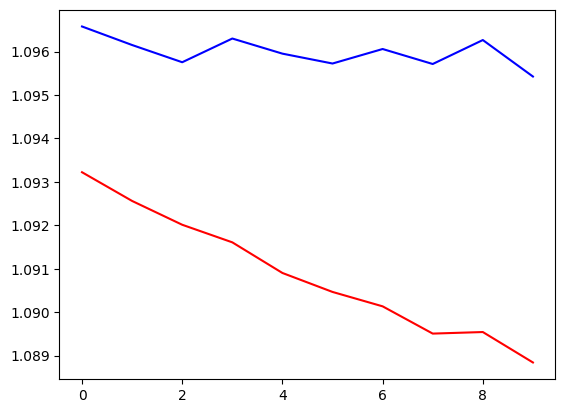

In [ ]:
plt.plot(train_loss, c='r')
plt.plot(val_loss, c='b')
plt.show()

MLP Model result for longformer, (data:eng_lchaim)


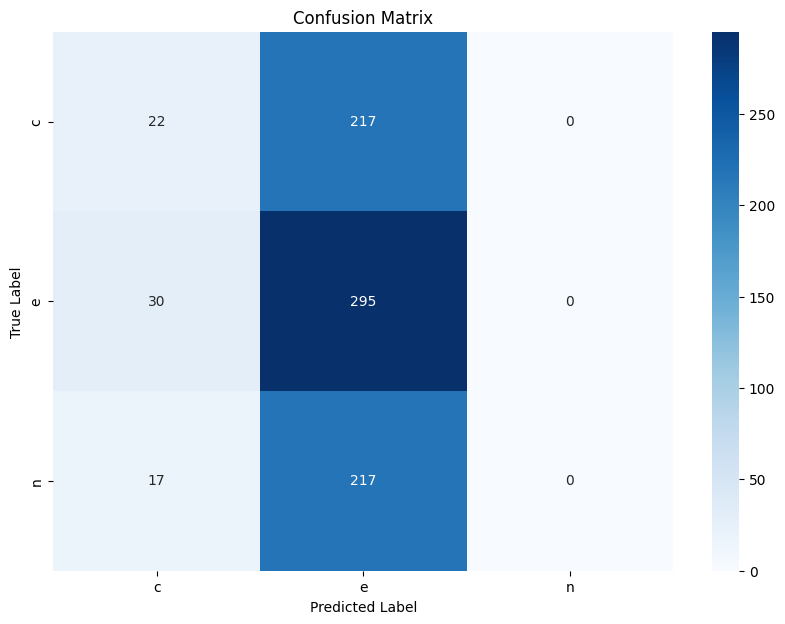

Classification Report:
              precision    recall  f1-score   support

           c    0.31884   0.09205   0.14286       239
           e    0.40466   0.90769   0.55977       325
           n    0.00000   0.00000   0.00000       234

    accuracy                        0.39724       798
   macro avg    0.24117   0.33325   0.23421       798
weighted avg    0.26030   0.39724   0.27076       798



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print(f'MLP Model result for {model_name}, (data:{dataset_name})')
res = evaluate_model(model=classifier_model, test_x=test_embeddings, y_test=y_test, labels_mapping=labels_mapping)

## MLP control

In [ ]:
model_name = 'longhero'
tranlation_type = 'aws_translation'
dataset_name = 'snli'
folder_to_save_data = f'____path____embeddings/{dataset_name}/{model_name}/'
folder_to_save_data

'____path____embeddings/snli/longhero/'

In [ ]:
train_embeddings = torch.load(f'{folder_to_save_data}/{model_name}_x_train.pt')
dev_embeddings = torch.load(f'{folder_to_save_data}/{model_name}_x_dev.pt')
test_embeddings = torch.load(f'{folder_to_save_data}/{model_name}_x_test.pt')

In [ ]:
y_test = snli_y_test
y_train = snli_y_train
y_dev = snli_y_dev

In [ ]:
set_seed(42)
classifier_model = MLPClassifier()
train_model(x_train=train_embeddings, y_train=y_train.long(), x_val=dev_embeddings, y_val=y_dev,
            model=classifier_model, learning_rate=1e-4, batch_size=32,
            epochs=5, checkpoints_dir_path='/content')



**Epoch #1


100%|██████████| 9378/9378 [00:13<00:00, 721.11it/s]


Finished training step, checking loss on train


100%|██████████| 9378/9378 [00:06<00:00, 1459.74it/s]


Checking loss on validation


100%|██████████| 63/63 [00:00<00:00, 1461.31it/s]


Train Epoch 1/5 Stats- Train Loss: 1.0349, Train Accuracy: 0.4753; Val Loss: 1.0319, Val Accuracy: 0.4682


**Epoch #2


100%|██████████| 9378/9378 [00:13<00:00, 719.92it/s]


Finished training step, checking loss on train


100%|██████████| 9378/9378 [00:06<00:00, 1438.05it/s]


Checking loss on validation


100%|██████████| 63/63 [00:00<00:00, 1473.06it/s]


Train Epoch 2/5 Stats- Train Loss: 1.0289, Train Accuracy: 0.4807; Val Loss: 1.0248, Val Accuracy: 0.4782


**Epoch #3


100%|██████████| 9378/9378 [00:13<00:00, 720.39it/s]


Finished training step, checking loss on train


100%|██████████| 9378/9378 [00:06<00:00, 1484.70it/s]


Checking loss on validation


100%|██████████| 63/63 [00:00<00:00, 1455.55it/s]


Train Epoch 3/5 Stats- Train Loss: 1.0280, Train Accuracy: 0.4840; Val Loss: 1.0241, Val Accuracy: 0.4807


**Epoch #4


100%|██████████| 9378/9378 [00:12<00:00, 722.38it/s]


Finished training step, checking loss on train


100%|██████████| 9378/9378 [00:06<00:00, 1404.80it/s]


Checking loss on validation


100%|██████████| 63/63 [00:00<00:00, 1497.62it/s]


Train Epoch 4/5 Stats- Train Loss: 1.0287, Train Accuracy: 0.4774; Val Loss: 1.0259, Val Accuracy: 0.4837


**Epoch #5


100%|██████████| 9378/9378 [00:13<00:00, 711.79it/s]


Finished training step, checking loss on train


100%|██████████| 9378/9378 [00:06<00:00, 1468.49it/s]


Checking loss on validation


100%|██████████| 63/63 [00:00<00:00, 1426.83it/s]

Train Epoch 5/5 Stats- Train Loss: 1.0268, Train Accuracy: 0.4828; Val Loss: 1.0254, Val Accuracy: 0.4762
Training complete!


In [ ]:
train_loss = np.load('/content/train_losses.npy')
val_loss = np.load('/content/val_losses.npy')

In [ ]:
plt.plot(train_loss, c='r')
plt.plot(val_loss, c='b')
plt.show()

In [ ]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print(f'MLP Model result for {model_name}, (data:{dataset_name})')
res = evaluate_model(model=classifier_model, test_x=test_embeddings, y_test=y_test, labels_mapping=labels_mapping)

MLP Model result for longhero, (data:snli)


Classification Report:
              precision    recall  f1-score   support

           c    0.50519   0.47557   0.48993       307
           e    0.48229   0.58224   0.52757       304
           n    0.41228   0.34432   0.37525       273

    accuracy                        0.47172       884
   macro avg    0.46659   0.46738   0.46425       884
weighted avg    0.46862   0.47172   0.46746       884



## MLP SNLI

In [ ]:
train_embeddings = torch.load(f'{folder_to_save_data}/snli/snli_{model_name}_x_train.pt')
dev_embeddings = torch.load(f'{folder_to_save_data}/snli/snli_{model_name}_x_dev.pt')
test_embeddings = torch.load(f'{folder_to_save_data}/snli/snli_{model_name}_x_test.pt')

In [ ]:
mappind_snli_train = snli_y_train != 3
mappind_snli_dev = snli_y_dev != 3
mappind_snli_test = snli_y_test != 3

In [ ]:
train_embeddings, snli_y_train = train_embeddings[mappind_snli_train], snli_y_train[mappind_snli_train]
dev_embeddings, snli_y_dev = dev_embeddings[mappind_snli_dev], snli_y_dev[mappind_snli_dev]
test_embeddings, snli_y_test = test_embeddings[mappind_snli_test], snli_y_test[mappind_snli_test]

In [ ]:
set_seed(42)
classifier_model = MLPClassifier()
train_model(x_train=train_embeddings, y_train=snli_y_train.long(), x_val=dev_embeddings, y_val=snli_y_dev,
            model=classifier_model, learning_rate=1e-4, batch_size=64,
            epochs=10, checkpoints_dir_path='/content')



**Epoch #1


100%|██████████| 4689/4689 [00:12<00:00, 361.28it/s]


Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 860.34it/s]


Checking loss on validation


100%|██████████| 32/32 [00:00<00:00, 428.64it/s]


Train Epoch 1/10 Stats- Train Loss: 1.0198, Train Accuracy: 0.4816; Val Loss: 1.0217, Val Accuracy: 0.4702


**Epoch #2


100%|██████████| 4689/4689 [00:12<00:00, 381.19it/s]


Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 880.93it/s]


Checking loss on validation


100%|██████████| 32/32 [00:00<00:00, 825.02it/s]


Train Epoch 2/10 Stats- Train Loss: 1.0026, Train Accuracy: 0.4963; Val Loss: 1.0040, Val Accuracy: 0.4897


**Epoch #3


100%|██████████| 4689/4689 [00:12<00:00, 385.61it/s]


Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 878.89it/s]


Checking loss on validation


100%|██████████| 32/32 [00:00<00:00, 876.05it/s]


Train Epoch 3/10 Stats- Train Loss: 0.9890, Train Accuracy: 0.5066; Val Loss: 0.9970, Val Accuracy: 0.4992


**Epoch #4


100%|██████████| 4689/4689 [00:12<00:00, 382.97it/s]


Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 873.59it/s]


Checking loss on validation


100%|██████████| 32/32 [00:00<00:00, 917.52it/s]


Train Epoch 4/10 Stats- Train Loss: 0.9805, Train Accuracy: 0.5123; Val Loss: 0.9876, Val Accuracy: 0.5018


**Epoch #5


100%|██████████| 4689/4689 [00:12<00:00, 384.69it/s]


Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 881.10it/s]


Checking loss on validation


100%|██████████| 32/32 [00:00<00:00, 879.26it/s]


Train Epoch 5/10 Stats- Train Loss: 0.9720, Train Accuracy: 0.5210; Val Loss: 0.9793, Val Accuracy: 0.5098


**Epoch #6


100%|██████████| 4689/4689 [00:12<00:00, 378.79it/s]


Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 873.52it/s]


Checking loss on validation


100%|██████████| 32/32 [00:00<00:00, 886.94it/s]


Train Epoch 6/10 Stats- Train Loss: 0.9668, Train Accuracy: 0.5259; Val Loss: 0.9770, Val Accuracy: 0.5193


**Epoch #7


100%|██████████| 4689/4689 [00:12<00:00, 381.73it/s]


Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 881.47it/s]


Checking loss on validation


100%|██████████| 32/32 [00:00<00:00, 879.59it/s]


Train Epoch 7/10 Stats- Train Loss: 0.9611, Train Accuracy: 0.5288; Val Loss: 0.9773, Val Accuracy: 0.5063


**Epoch #8


100%|██████████| 4689/4689 [00:12<00:00, 384.37it/s]


Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 866.68it/s]


Checking loss on validation


100%|██████████| 32/32 [00:00<00:00, 865.08it/s]


Train Epoch 8/10 Stats- Train Loss: 0.9557, Train Accuracy: 0.5333; Val Loss: 0.9802, Val Accuracy: 0.5058


**Epoch #9


100%|██████████| 4689/4689 [00:12<00:00, 380.89it/s]


Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 873.97it/s]


Checking loss on validation


100%|██████████| 32/32 [00:00<00:00, 868.16it/s]


Train Epoch 9/10 Stats- Train Loss: 0.9515, Train Accuracy: 0.5355; Val Loss: 0.9704, Val Accuracy: 0.5188


**Epoch #10


100%|██████████| 4689/4689 [00:12<00:00, 376.21it/s]


Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 867.43it/s]


Checking loss on validation


100%|██████████| 32/32 [00:00<00:00, 896.94it/s]

Train Epoch 10/10 Stats- Train Loss: 0.9496, Train Accuracy: 0.5369; Val Loss: 0.9719, Val Accuracy: 0.5163
Training complete!


MLP Model result for alephbert on HEB-SNLI


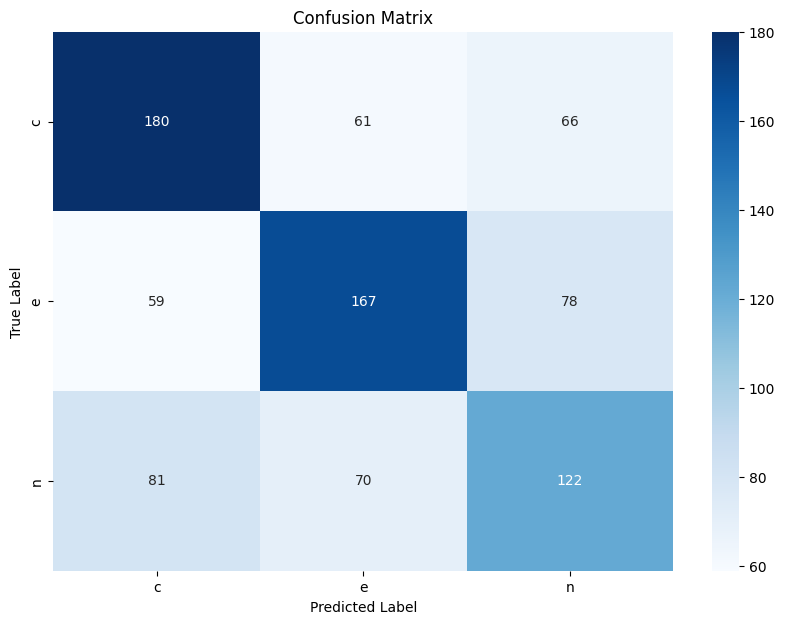

Classification Report:
              precision    recall  f1-score   support

           c       0.56      0.59      0.57       307
           e       0.56      0.55      0.55       304
           n       0.46      0.45      0.45       273

    accuracy                           0.53       884
   macro avg       0.53      0.53      0.53       884
weighted avg       0.53      0.53      0.53       884



In [ ]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print(f'MLP Model result for {model_name} on HEB-SNLI')
res = evaluate_model(model=classifier_model, test_x=test_embeddings, y_test=snli_y_test, labels_mapping=labels_mapping)

In [ ]:
snli_ft_path = '____path____finetuning/snli'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(snli_ft_path)
model = AutoModel.from_pretrained(snli_ft_path, num_labels=3)

## preprocess lchaim dataset

In [ ]:
test_df = pd.DataFrame(test_data)
test_df['paires'] = test_df['premise'] + ' [SEP] ' + test_df['hypothesis'] + ' [SEP] '
test_pairs = test_df['paires'].tolist()
tokenized_test = tokenize_one_sample(tokenizer=tokenizer, sample=test_pairs, max_length=512)

In [ ]:
lchaim_test_data = Dataset.from_dict({
    'input_ids': tokenized_test['input_ids'],
    'attention_mask': tokenized_test['attention_mask'],
    'labels': y_test
})

In [ ]:
snli_trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

## run results on test

In [ ]:
results = snli_trainer.predict(test_dataset=lchaim_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics

Epoch,Training Loss,Validation Loss


(3,)

AWS LCHAIM test set after FT on SNLI


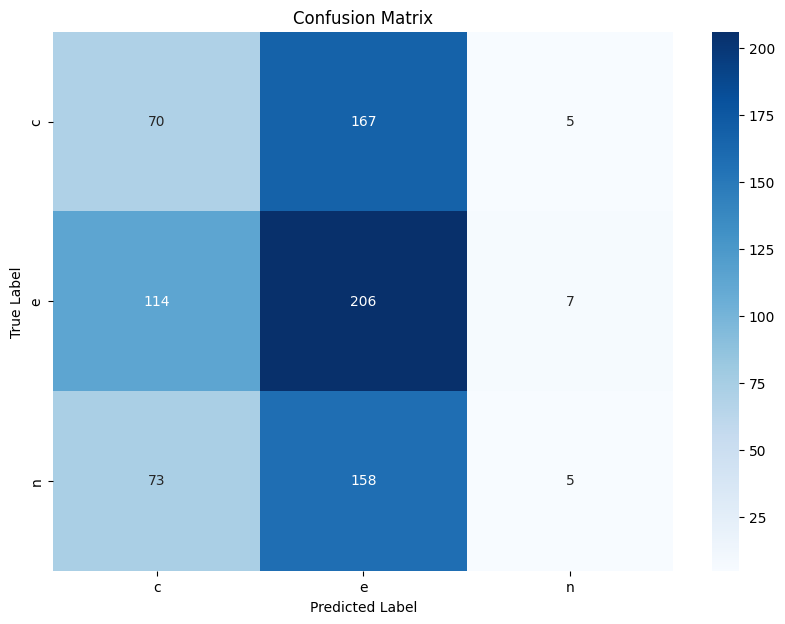

Classification Report:
              precision    recall  f1-score   support

           c       0.27      0.29      0.28       242
           e       0.39      0.63      0.48       327
           n       0.29      0.02      0.04       236

    accuracy                           0.35       805
   macro avg       0.32      0.31      0.27       805
weighted avg       0.33      0.35      0.29       805



In [ ]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print('AWS LCHAIM test set after FT on SNLI')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=y_test.numpy(), labels_mapping=labels_mapping)

# error analysis

In [ ]:
def extract_text_length_accuracy(df, text_columns_list, predicted_label_array, model_name, bin_size, label_list_to_check=['e','c','n'], label_col_name='label', dataset_name='Dataset'):
    analysis_df = df[text_columns_list].copy()
    analysis_df['true_label'] = df[label_col_name]
    analysis_df['predicted_label'] = predicted_label_array
    analysis_df = analysis_df[analysis_df['true_label'].isin(label_list_to_check)]

    # Combine text columns and calculate text length for all samples
    analysis_df['text'] = analysis_df[text_columns_list].apply(lambda x: ' '.join(x.astype(str)), axis=1)
    analysis_df['text_length'] = analysis_df['text'].apply(len)

    # Calculate the bin edges and bin labels based on the specified bin size
    max_length = analysis_df['text_length'].max()
    bins = np.arange(0, max_length + bin_size, bin_size)
    bin_labels = (bins[:-1] + bins[1:])

    # Assign each text length to a bin
    analysis_df['length_bin'] = pd.cut(analysis_df['text_length'], bins=bins, labels=bin_labels, right=False)

    # Group by text length bin and compute accuracy
    grouped = analysis_df.groupby('length_bin').apply(
        lambda group: (group['predicted_label'] == group['true_label']).mean()
    ).reset_index(name='accuracy')

    # return analysis_df

    # Plot accuracy for each text length bin as a line plot
    plt.figure(figsize=(12, 6))
    plt.plot(grouped['length_bin'], grouped['accuracy'], label=f'Accuracy per Text Length Bin (Size {bin_size})', color='blue', marker='o')
    plt.title(f'Accuracy per Text Length Bin - {model_name} on {dataset_name}')
    plt.xlabel('Text Length Bin')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
def extract_text_length_histogram_with_errors(df, text_columns_list, predicted_label_array, model_name, error_color='red', label_list_to_check=['e','c','n'], label_col_name='label', dataset_name='LCHAIM', return_df=False):
    analysis_df = df[text_columns_list].copy()
    analysis_df['true_label'] = df[label_col_name]
    analysis_df['predicted_label'] = predicted_label_array

    # Combine text columns and calculate text length for all samples
    analysis_df['text'] = analysis_df[text_columns_list].apply(lambda x: ' '.join(x.astype(str)), axis=1)
    analysis_df['text_length'] = analysis_df['text'].apply(len)
    analysis_df = analysis_df[analysis_df['true_label'].isin(label_list_to_check)]

    # Prepare the DataFrame with wrong predictions
    errors_df = analysis_df[analysis_df['true_label'].isin(label_list_to_check) & (analysis_df['true_label'] != analysis_df['predicted_label'])]

    # Get text lengths for all samples and for errors
    all_lengths = analysis_df['text_length']
    error_lengths = errors_df['text_length']

    # Define the number of bins for the histogram
    bins = 50

    # Plot histogram for all samples
    plt.figure(figsize=(12, 6))
    counts, bin_edges, _ = plt.hist(all_lengths, bins=bins, color='skyblue', edgecolor='black', label='All Samples')

    # Get the width of the bins
    bin_width = bin_edges[1] - bin_edges[0]

    # Count the number of wrong predictions per bin
    counts_errors, _ = np.histogram(error_lengths, bins=bin_edges)

    # Overplot the errors
    centers = bin_edges[:-1] + bin_width / 2  # calculate the center of bins
    plt.bar(centers, counts_errors, width=bin_width, align='center', color=error_color, edgecolor='black', alpha=0.5, label='Errors')

    # Plot annotations and legend
    plt.title(f'Histogram of Text Lengths with Errors Highlighted in {error_color} (labels: {label_list_to_check}), model: {model_name}, dataset: {dataset_name}')
    plt.xlabel(f'Text Length ({text_columns_list})')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.legend()
    plt.show()

    if return_df:
        return analysis_df

In [ ]:
test_df = pd.DataFrame(test_data)

In [ ]:
predictions = np.load('/content/LongHero_preds_for___.npy')

Test results with longhero ft snli+lchaim


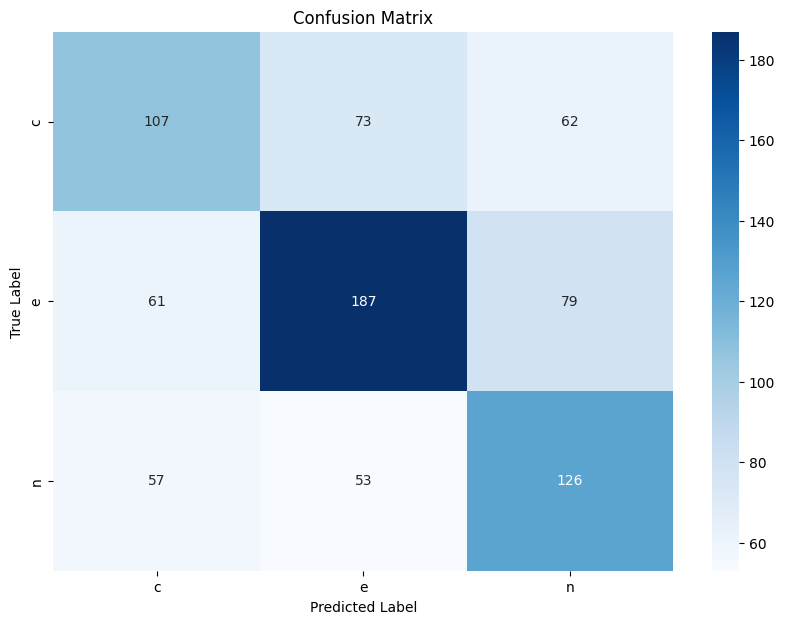

Classification Report:
              precision    recall  f1-score   support

           c    0.47556   0.44215   0.45824       242
           e    0.59744   0.57187   0.58438       327
           n    0.47191   0.53390   0.50099       236

    accuracy                        0.52174       805
   macro avg    0.51497   0.51597   0.51454       805
weighted avg    0.52400   0.52174   0.52201       805



In [ ]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print('Test results with longhero ft snli+lchaim')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=y_test.numpy(), labels_mapping=labels_mapping)

In [ ]:
preds_int = predictions.argmax(axis=1)
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
inv_map = {v: k for k, v in labels_mapping.items()}
preds = np.array([inv_map[label_int] for label_int in preds_int])

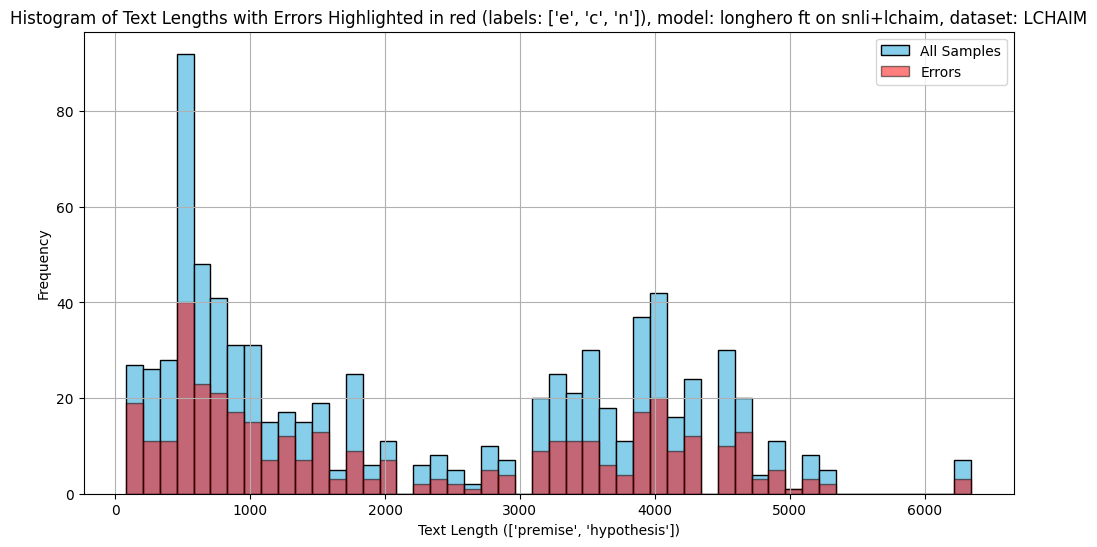

In [ ]:
r = extract_text_length_histogram_with_errors(df=test_df, text_columns_list=['premise', 'hypothesis'], predicted_label_array=preds, model_name='longhero ft on snli+lchaim', return_df=True)

In [ ]:
pd.read_parquet('/content/results_ft_longhero_lchaim.parquet')

,premise,hypothesis,true_label,predicted_label,text,text_length
0,"זמן מה בליל ה -1 באוקטובר, מועדון קופקבנה נשרף...","אם חברת הביטוח תשלם במלואה, ג'ון הודג'ס עומד ל...",n,n,"זמן מה בליל ה -1 באוקטובר, מועדון קופקבנה נשרף...",440
1,קטע זה מספק מידע על סבסוד אנרגיה מתחדשת והשפעת...,חברת בת ממשלתית יכולה להפחית את עלות האנרגיה ה...,e,e,קטע זה מספק מידע על סבסוד אנרגיה מתחדשת והשפעת...,732
2,קטע זה מספק מידע על סבסוד אנרגיה מתחדשת והשפעת...,דלקים מאובנים זולים כיום מצורות של אנרגיה מתחדשת.,e,n,קטע זה מספק מידע על סבסוד אנרגיה מתחדשת והשפעת...,729
3,קטע זה מספק מידע על סבסוד אנרגיה מתחדשת והשפעת...,הטמפרטורה הממוצעת בבריטניה צפויה לעלות ב -4% ע...,c,n,קטע זה מספק מידע על סבסוד אנרגיה מתחדשת והשפעת...,733
4,השנה רוב החנויות וחנויות הכלבו מציעות פרסים וה...,הרבה סחורות זמינות אך המכירה לא עולה. אין שום ...,e,c,השנה רוב החנויות וחנויות הכלבו מציעות פרסים וה...,138
...,...,...,...,...,...,...
800,"זמן מה בליל ה -1 באוקטובר, מועדון קופקבנה נשרף...",ג'ון הודג'ס יכול היה להיות במועדון כשהשריפה הת...,e,e,"זמן מה בליל ה -1 באוקטובר, מועדון קופקבנה נשרף...",430
801,"זמן מה בליל ה -1 באוקטובר, מועדון קופקבנה נשרף...",הדירה בה נמצאה התוכנית קרובה למועדון.,n,n,"זמן מה בליל ה -1 באוקטובר, מועדון קופקבנה נשרף...",416
802,"זמן מה בליל ה -1 באוקטובר, מועדון קופקבנה נשרף...",בן משפחתו של ג'ון הודג'ס מת בשריפה,c,n,"זמן מה בליל ה -1 באוקטובר, מועדון קופקבנה נשרף...",413
803,"זמן מה בליל ה -1 באוקטובר, מועדון קופקבנה נשרף...",יש עילה ברורה לעצור את ג'ון הודג'ס בגין הצתה.,c,c,"זמן מה בליל ה -1 באוקטובר, מועדון קופקבנה נשרף...",424


In [ ]:
r.to_parquet('results_ft_longhero_lchaim.parquet')

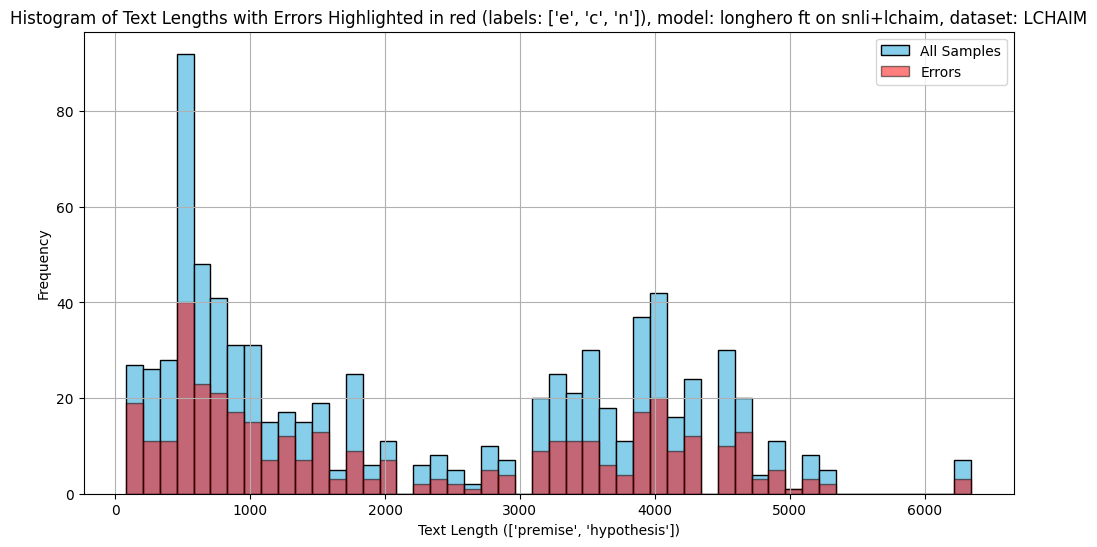

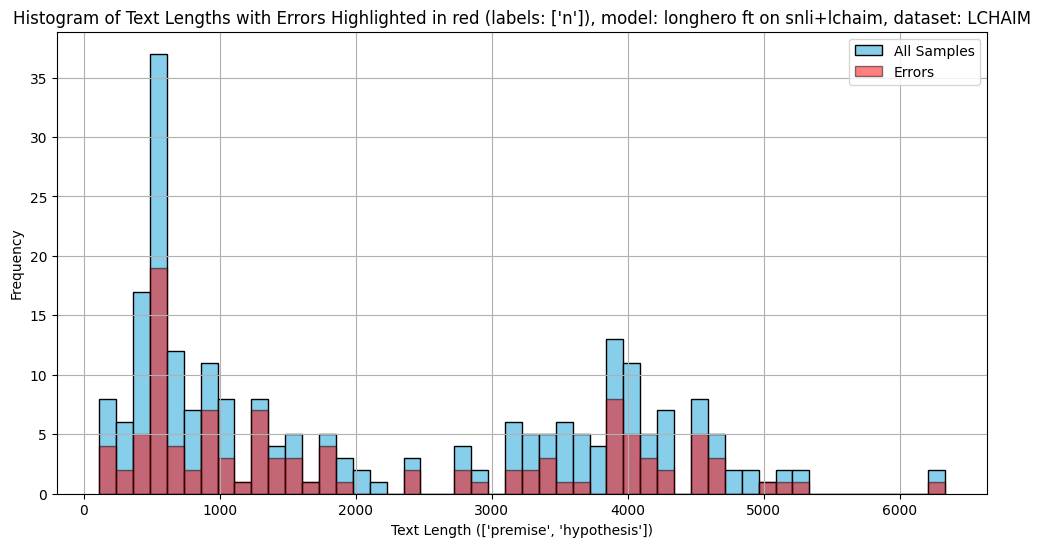

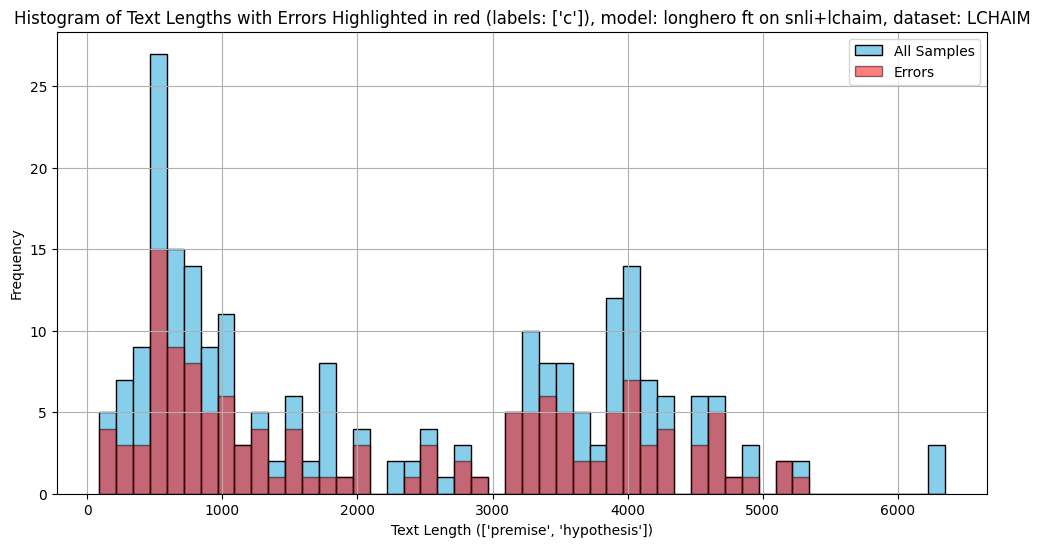

In [ ]:
extract_text_length_histogram_with_errors(df=test_df, text_columns_list=['premise', 'hypothesis'], predicted_label_array=preds, model_name='longhero ft on snli+lchaim')


for label_to_check in ['n','c','e']:
  extract_text_length_histogram_with_errors(df=test_df, text_columns_list=['premise', 'hypothesis'], predicted_label_array=preds, model_name='longhero ft on snli+lchaim', label_list_to_check=[label_to_check])

<ipython-input-189-f0cbb0dd130d>:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = analysis_df.groupby('length_bin').apply(


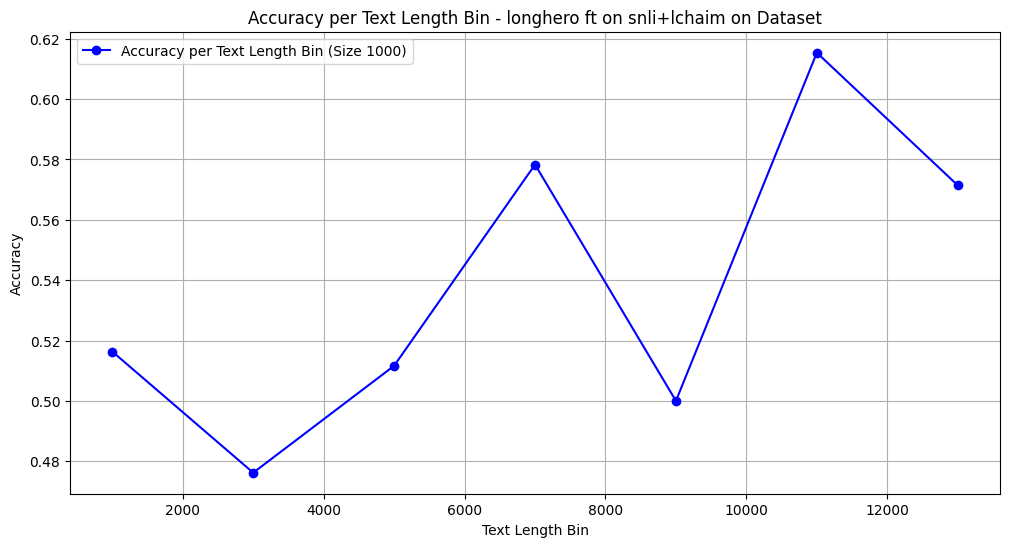

In [ ]:
d = extract_text_length_accuracy(df=test_df, text_columns_list=['premise', 'hypothesis'], predicted_label_array=preds, model_name='longhero ft on snli+lchaim', bin_size=1000)

In [ ]:
bins = np.sort(d.length_bin.unique())

In [ ]:
bins

array([  500,  1500,  2500,  3500,  4500,  5500,  6500,  7500,  8500,
        9500, 10500, 12500])

In [ ]:
def get_accuracy_res(df, true_label_col_name='true_label', predicted_label_col_name='predicted_label'):
  samples_in_bin = df.shape[0]
  true_preds = f[df[predicted_label_col_name] == df[true_label_col_name]].shape[0]
  return true_preds / samples_in_bin

In [ ]:
acc_per_bin = []
for bin in bins:
  f = d[d.length_bin == bin]
  acc_per_bin.append(get_accuracy_res(df=f))


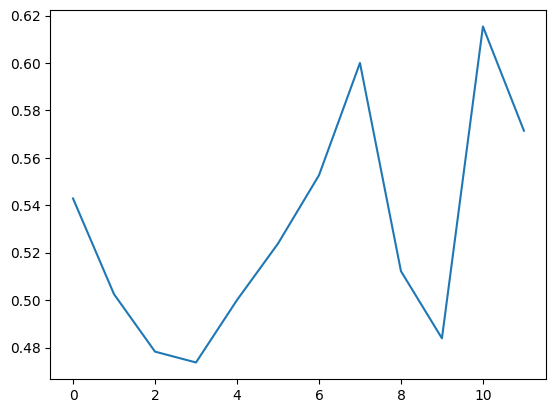

In [ ]:
plt.plot(acc_per_bin)
# plt.xticks(bins)
plt.show()

In [ ]:
test_df['pred'] = preds
test_df['premise_len'] = test_df['premise'].apply(len)
mistakes_df = test_df[test_df.label != test_df.pred]

In [ ]:
def extract_example_(df, label_type):
  example = df[df.label == label_type].sample(random_state=424)
  return example

In [ ]:
c = []
for label_type in ['e', 'c', 'n']:
  c.append(extract_example_(df=mistakes_df, label_type=label_type))
examples_ = pd.concat(c).reset_index(drop=True)
examples_

,uid,premise,hypothesis,label,pred,premise_len
0,id_64,"כיום, המונח סוריאליסטי משמש לציון אפקט דמיוני ...",עבודת סלבדור דאליס פופולרית יותר מתפוקת אנדרה ...,e,n,885
1,id_324,מתנדבים תודה שהתנדבתם לעבוד אחד על אחד עם חלק ...,אתה לא יכול לקחת תרופות בזמן הלימודים.,c,n,1280
2,id_547,מה המטרה של השגת ידע? הייתי מוצא מוסד שבו כל א...,מדעי האש הם אקדמיים מכדי לעזור לאנשים להיות טו...,n,c,3155


In [ ]:
examples_.to_csv('examples_of_errors.csv')

In [ ]:
# tokenizer = AutoTokenizer.from_pretrained('dicta-il/dictalm2.0')
tokenizer = AutoTokenizer.from_pretrained('HeNLP/LongHeRo')

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
df = pd.read_parquet('/content/results_ft_longhero_lchaim.parquet')

In [ ]:
df['text'] = df[['premise', 'hypothesis']].apply(lambda x: ' '.join(x.astype(str)), axis=1)

In [ ]:
def get_n_tokens(x, max_length=4096):
  return len(tokenizer(x)['input_ids'])
  # return len(tokenizer(x, return_tensors="pt", truncation=True, padding="max_length", max_length=max_length)['input_ids'])

In [ ]:
df['n_tokens'] = df['text'].apply(lambda x: get_n_tokens(x))

In [ ]:
bin_size = 50

In [ ]:
max_length = df['n_tokens'].max()
bins = np.arange(0, max_length + bin_size, bin_size)
bin_labels = (bins[:-1] + bins[1:])
# Assign each text length to a bin
df['length_bin'] = pd.cut(df['n_tokens'], bins=bins, labels=bin_labels, right=False)
df['length_bin'] = ((df['n_tokens'] // bin_size))
x_values = df['length_bin'].drop_duplicates().sort_values().tolist()
x_tick_labels = [i*bin_size for i in x_values]  # Custom tick labels corresponding to the x positions
# Group by text length bin and compute accuracy
grouped = df.groupby('length_bin').apply(
    lambda group: (group['predicted_label'] == group['true_label']).mean()
).reset_index(name='accuracy')

# Plot accuracy for each text length bin as a line plot
plt.figure(figsize=(12, 6))
plt.plot(grouped['length_bin'], grouped['accuracy'], label=f'Accuracy per Text Length Bin (Size {bin_size})', color='blue', marker='o')
plt.xticks(ticks=x_values, labels=x_tick_labels)
plt.title(f'Accuracy per Text Length Bin')
plt.xlabel('Text Length Bin')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()